In [1]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA

In [2]:
def score_dataset(X, y, model=RandomForestRegressor(random_state=1)):
    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(score.mean())

In [3]:
# Utility functions from Kaggle Tutorial(Feature engineering)
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

In [4]:
def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

In [5]:
rain_file_origin_path = 'data/Rainfall.csv'
rain_origin_data = pd.read_csv(rain_file_origin_path)
rain_file_path = 'data/train.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "data/test.csv"
test_data = pd.read_csv(test_file_path)

In [6]:
test_data.fillna(value=160, inplace=True)
X_test = test_data

In [7]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall

In [8]:
score_dataset(X, y)

0.8776175077070999


In [9]:
rain_origin_data

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7
...,...,...,...,...,...,...,...,...,...,...,...,...
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9


In [10]:
X_origin = rain_origin_data.drop(labels=("rainfall"), axis=1)

In [15]:
display(rain_origin_data)

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7
...,...,...,...,...,...,...,...,...,...,...,...,...
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9


In [16]:
display(rain_data)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,2185,361,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2186,2186,362,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2187,2187,363,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2188,2188,364,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1


In [8]:
#cols = X.columns
cols = ["cloud", "sunshine"]
cols_for_scaling = X.loc[:, cols]
cols_for_scaling

,cloud,sunshine
0,88.0,1.1
1,91.0,0.0
2,47.0,8.3
3,95.0,0.0
4,45.0,3.6
...,...,...
2185,88.0,0.1
2186,88.0,0.0
2187,79.0,5.0
2188,93.0,0.1


In [9]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(cols_for_scaling)
X_scaled = pd.DataFrame(X_scaled, columns=[cols])
X_test_scaled = ms.fit_transform(cols_for_scaling)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[cols])

X_scaled

,cloud,sunshine
0,0.877551,0.090909
1,0.908163,0.000000
2,0.459184,0.685950
3,0.948980,0.000000
4,0.438776,0.297521
...,...,...
2185,0.877551,0.008264
2186,0.877551,0.000000
2187,0.785714,0.413223
2188,0.928571,0.008264


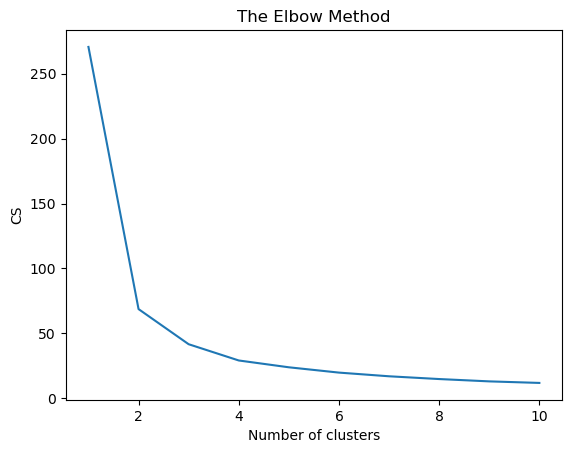

In [10]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [11]:
kmeans = KMeans(n_clusters=2, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 1718 out of 2190 samples were correctly labeled.
Accuracy score: 0.78


In [12]:
#cluster = kmeans.fit(X_scaled)
X_scaled["cluster"] = kmeans.predict(X_scaled)

In [13]:
kmeans.fit(X_test_scaled)
X_test_scaled["cluster"] = kmeans.predict(X_test_scaled)

In [14]:
X_cd = kmeans.fit_transform(X_scaled)
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_test_cd = kmeans.fit_transform(X_test_scaled)
X_test_cd = pd.DataFrame(X_test_cd, columns=[f"Centroid_{i}" for i in range(X_test_cd.shape[1])])

In [15]:
X = X.join(X_cd)
X_test = X_test.join(X_test_cd)

In [16]:
X["cluster"] = X_scaled["cluster"]
X
X_test["cluster"] = X_test_scaled["cluster"]
X_test

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Centroid_0,Centroid_1,cluster
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,1.201815,0.031709,1
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,1.256857,0.124249,1
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0.104357,1.218766,0
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,1.268664,0.146852,1
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,0.401087,1.098443,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,2915,361,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,1.248804,0.114143,1
726,2916,362,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,1.248804,0.114143,1
727,2917,363,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,1.248008,0.109646,1
728,2918,364,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,1.248804,0.114143,1


In [17]:
score_dataset(X, y)

0.879723170864861


In [18]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.202280
Centroid_1       0.194488
sunshine         0.166422
Centroid_0       0.153806
humidity         0.130347
cluster          0.097866
id               0.068340
day              0.057267
dewpoint         0.034847
mintemp          0.029092
temparature      0.025696
maxtemp          0.016384
winddirection    0.013790
pressure         0.012865
windspeed        0.007016
Name: MI Scores, dtype: float64

In [19]:
#X = X.drop(labels = ("day"), axis=1)
#X_test = X_test.drop(labels = ("day"), axis=1)


In [20]:
score_dataset(X, y)

0.879723170864861


In [21]:
X = X.drop(labels = ("windspeed"), axis=1)
X_test = X_test.drop(labels = ("windspeed"), axis=1)
score_dataset(X, y)

0.8732416052761429


In [22]:
#X = X.drop(labels = ("id"), axis=1)
#X_test = X_test.drop(labels = ("id"), axis=1)
#score_dataset(X, y)

In [23]:
features = ["cloud", "sunshine", "Centroid_1", "humidity", "Centroid_0", "cluster", "winddirection"]
Z = X.loc[:, features]
W = X_test.loc[:, features]
# `apply_pca`, defined above, reproduces the code from the tutorial
pca, X_pca, loadings = apply_pca(Z)
print(loadings)

                    PC1       PC2       PC3       PC4       PC5       PC6  \
cloud         -0.387466 -0.135677 -0.113339 -0.870537 -0.217870  0.110099   
sunshine       0.430002 -0.059929 -0.084681  0.045117 -0.878408  0.025159   
Centroid_1     0.440171 -0.004119 -0.205026 -0.099169  0.133428  0.630001   
humidity      -0.287494 -0.364741 -0.834215  0.295878 -0.020539 -0.020728   
Centroid_0    -0.434070  0.034014  0.217638  0.275260 -0.135521  0.749406   
cluster       -0.432663  0.024467  0.241795  0.257539 -0.370928 -0.167892   
winddirection  0.113801 -0.918255  0.369056  0.025658  0.082176  0.010784   

                    PC7  
cloud          0.034545  
sunshine      -0.173395  
Centroid_1     0.582801  
humidity      -0.001459  
Centroid_0    -0.327592  
cluster        0.722245  
winddirection  0.011287  


In [24]:
X = X.join(X_pca)
X

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,...,Centroid_0,Centroid_1,cluster,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,...,1.201815,0.031709,1,-1.851954,0.280988,-0.233535,0.028768,-0.056916,-0.083313,-0.086392
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,...,1.256857,0.124249,1,-2.329317,0.020562,-1.138964,0.185224,0.149552,0.103399,0.033236
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,...,0.104357,1.218766,0,3.254315,0.776856,-0.292662,0.239530,0.132142,-0.226237,0.059869
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,...,1.268664,0.146852,1,-2.393055,-0.123645,-1.121327,-0.002084,0.113810,0.175081,0.059131
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,...,0.401087,1.098443,0,3.170212,2.311763,2.335251,-0.407891,1.208451,0.115017,-0.059336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,2185,361,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,...,1.244331,0.106078,1,-2.344551,0.061988,-1.381167,0.400088,0.145051,0.037367,0.009514
2186,2186,362,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,...,1.248804,0.114143,1,-2.118435,0.229669,-0.692124,0.175571,0.196100,0.070758,0.022649
2187,2187,363,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,...,1.058299,0.309166,1,-0.564877,0.875334,0.320621,0.065690,-0.780541,0.010881,0.116074
2188,2188,364,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,...,1.258185,0.127707,1,-2.262439,0.258977,-0.879912,-0.026986,0.099278,0.129193,0.034344


In [25]:
pca, X_pca, loadings = apply_pca(Z)
X_test = X_test.join(X_pca)

In [26]:
#když bylo vyhozené id a day bylo to 0.8745862843729195
score_dataset(X, y)

0.8782342871622587


In [27]:
X

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,...,Centroid_0,Centroid_1,cluster,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,...,1.201815,0.031709,1,-1.851954,0.280988,-0.233535,0.028768,-0.056916,-0.083313,-0.086392
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,...,1.256857,0.124249,1,-2.329317,0.020562,-1.138964,0.185224,0.149552,0.103399,0.033236
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,...,0.104357,1.218766,0,3.254315,0.776856,-0.292662,0.239530,0.132142,-0.226237,0.059869
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,...,1.268664,0.146852,1,-2.393055,-0.123645,-1.121327,-0.002084,0.113810,0.175081,0.059131
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,...,0.401087,1.098443,0,3.170212,2.311763,2.335251,-0.407891,1.208451,0.115017,-0.059336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,2185,361,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,...,1.244331,0.106078,1,-2.344551,0.061988,-1.381167,0.400088,0.145051,0.037367,0.009514
2186,2186,362,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,...,1.248804,0.114143,1,-2.118435,0.229669,-0.692124,0.175571,0.196100,0.070758,0.022649
2187,2187,363,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,...,1.058299,0.309166,1,-0.564877,0.875334,0.320621,0.065690,-0.780541,0.010881,0.116074
2188,2188,364,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,...,1.258185,0.127707,1,-2.262439,0.258977,-0.879912,-0.026986,0.099278,0.129193,0.034344


In [28]:
model=RandomForestRegressor(random_state=1)
model.fit(X, y)
rf_test_preds = model.predict(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=1,
    class_weight="balanced",
    solver="liblinear",
)
score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print(score.mean())

0.8928731762065094


In [30]:
#model.fit(X, y)
#rf_test_preds = model.predict(X_test)

In [31]:
#X_test["id"] = test_data["id"]
#X_test["rainfall"] = rf_test_preds
#X_test.to_csv('submission_k-mean_PCA_2.csv', columns=['id','rainfall'], index=False)